# 4. Support Vector Regression

A fundamentally different way to draw the curve.

SVR fits a tube of width epsilon around the data and only penalizes points that
fall outside it, so days it already predicts well within tolerance stop
contributing to the loss entirely. With an RBF kernel it maps the features into a
high-dimensional space and fits a linear surface there, which comes back as a
smooth nonlinear surface in the original features.

That smoothness is the interesting contrast with the tree models. Trees produce
step functions; SVR produces a continuous surface. Whichever fits LA's AQI better
tells us something about whether the weather-to-smog relationship is gradual or
threshold-like.

## Setup

Loads the shared split written by `notebooks/build_modeling_dataset.ipynb`.

In [1]:
import sys
from pathlib import Path

_here = Path.cwd()
sys.path.insert(0, str(_here if _here.name == 'models' else _here / 'models'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from model_utils import load_split, evaluate, diagnostic_plots, RANDOM_STATE, PLOT_STYLE

X_train, y_train, X_test, y_test, meta = load_split()

print(f"train: {X_train.shape}  {meta['train_range'][0]} -> {meta['train_range'][1]}")
print(f"test:  {X_test.shape}  {meta['test_range'][0]} -> {meta['test_range'][1]}")
print(f"target: {meta['target']}  |  {meta['n_features']} features")

train: (2554, 37)  2016-01-04 -> 2022-12-31
test:  (1095, 37)  2023-01-01 -> 2025-12-30
target: daily_aqi  |  37 features


## Tuning on the training set only

Hyperparameters are chosen with `TimeSeriesSplit` cross-validation **inside the
training years**, never touching 2023–2025. Ordinary k-fold would shuffle the
calendar and let each fold train on days that come after its validation days;
`TimeSeriesSplit` always validates on a window that follows its training window,
which is the same forward-in-time question the final test asks.

Scaling is not optional for this model — it measures distances in feature space,
and the raw columns run from `is_weekend` (0 to 1) to `calm_hours` (0 to 24) to
temperature in degrees. Without standardization the widest-ranged columns would
dominate purely because of their units. The scaler lives *inside* the pipeline so
it is refit on each CV fold's training data only, never leaking the validation
fold's statistics.

In [2]:
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

MODEL_NAME = 'SVR'
tscv = TimeSeriesSplit(n_splits=5)

pipe = Pipeline([
    ('scale', StandardScaler()),
    ('model', SVR(kernel='rbf')),
])

grid = {
    'model__C':       [1, 10, 100, 300, 1000],
    'model__gamma':   ['scale', 0.01, 0.05],
    'model__epsilon': [1.0, 5.0, 10.0, 20.0],
}

search = GridSearchCV(pipe, grid, cv=tscv,
                      scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
search.fit(X_train, y_train)

best = search.best_estimator_
print(f'\nbest params: {search.best_params_}')
print(f'best CV RMSE: {-search.best_score_:.3f}\n')

result = evaluate(MODEL_NAME, best, X_train, y_train, X_test, y_test,
                  params=search.best_params_,
                  notes=f'RBF kernel, StandardScaler pipeline, GridSearchCV over {len(search.cv_results_["params"])} combos')

Fitting 5 folds for each of 60 candidates, totalling 300 fits



best params: {'model__C': 300, 'model__epsilon': 10.0, 'model__gamma': 0.01}
best CV RMSE: 21.714



=== SVR ===
metric           train      test
RMSE            17.246    18.851
MAE             12.130    13.565
R2               0.783     0.782
MAPE %          13.348    15.822
within10 %      57.674    48.950

overfit gap (test RMSE - train RMSE): +1.605
saved -> models/results/svr.json


## Diagnostics

Three views of the same test predictions: how they line up against
truth, whether the errors are patterned or random, and how the model tracks the
actual 2023–2025 series day by day.

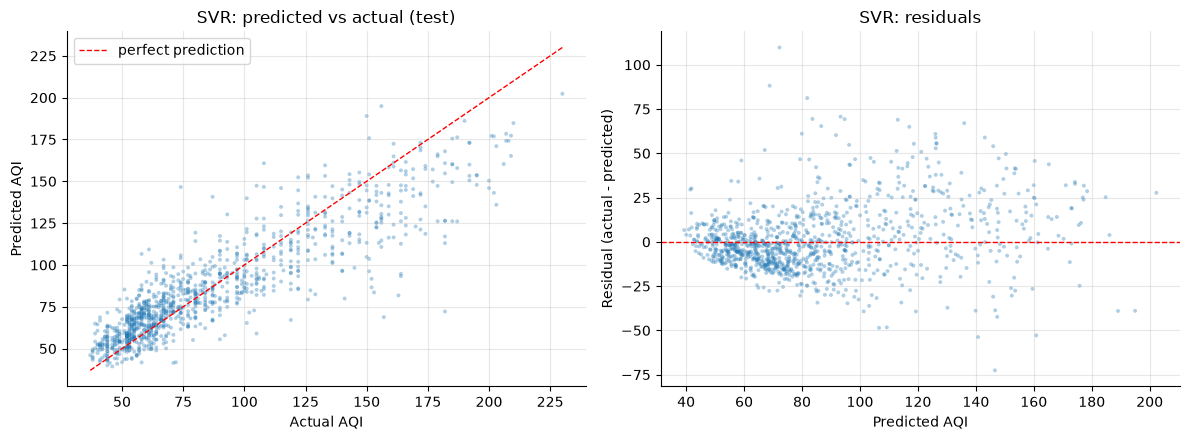

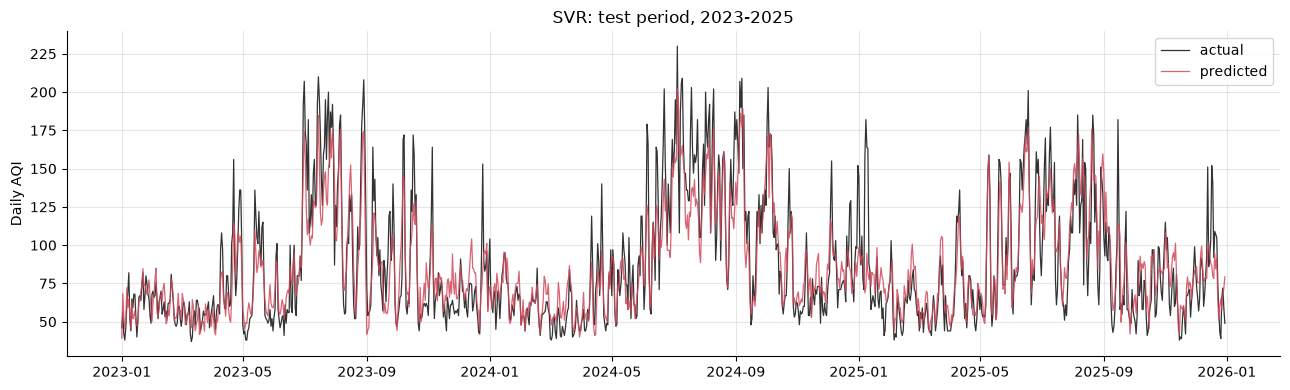

In [3]:
diagnostic_plots(MODEL_NAME, y_test, best.predict(X_test), meta['test_dates'])

## How much of the training set became support vectors

The support vectors are the days that landed outside the epsilon tube — the ones
actually defining the fitted surface. A high fraction means the model needed most
of the data to describe the shape, which is a hint that it is memorizing rather
than generalizing.

In [4]:
svr = best.named_steps['model']
n_sv = len(svr.support_)
print(f'support vectors: {n_sv} of {len(X_train)} training days ({n_sv/len(X_train):.1%})')
print(f'epsilon tube half-width: {svr.epsilon} AQI points')
print(f'C (error penalty): {svr.C}')

resid_train = np.asarray(y_train) - best.predict(X_train)
inside = np.mean(np.abs(resid_train) <= svr.epsilon) * 100
print(f'\ntraining days predicted inside the epsilon tube: {inside:.1f}%')

support vectors: 1248 of 2554 training days (48.9%)
epsilon tube half-width: 10.0 AQI points
C (error penalty): 300



training days predicted inside the epsilon tube: 57.7%


## What this told us

**Test RMSE 18.9, R² 0.782 — the best of all six models**, and it wins on the
metric that matters most for trustworthiness: an overfit gap of just **+1.6**,
against +10.7 for boosting and +11.5 for the forest. It is the only strong model
whose training score is an honest preview of its test score.

That is the epsilon tube doing its job. With `epsilon=10`, any training day already
predicted within 10 AQI points contributes nothing to the loss, so the model never
spends capacity chasing noise it has already fit well enough. 57.7% of training days
land inside the tube and only 48.9% of days become support vectors — it describes
the surface with about half the data, where KNN needs all of it.

A nice coincidence worth noting: `epsilon=10` was tuned by cross-validation with no
knowledge of our `within 10 AQI` reporting metric, and landed on the same
threshold — 10 AQI points is roughly where "close enough" begins for this problem
from both directions.

`C=300` was verified against a wider grid (up to C=3000, epsilon up to 20) and
remains the interior optimum, so this is not a boundary artifact.

The remaining weakness is visible in the residual plot: like every model here, it
under-predicts the worst days. Smooth surfaces do not do spikes.